# Import

In [71]:
import pandas as pd
import numpy as np

import pingouin as pg

import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [60]:
np.random.seed(1212)

In [61]:
n_groups = 3
n_sub_per_group = 50
groups = ['G1', 'G2', 'G3']
times = ['T1', 'T2', 'T3'] 

In [77]:
data = []
subject_id = 1
for g in groups:
    for _ in range(n_sub_per_group):
        subject_effect = np.random.normal(0, 3)
        
        if g == 'G1':
            base_mean = 50
        elif g == 'G2':
            base_mean = 55
        else:  # G3
            base_mean = 60
            
        means_by_time = {
            'T1': base_mean,
            'T2': base_mean + 5,
            'T3': base_mean + 8
        }
        
        for t in times:
            score = np.random.normal(means_by_time[t] + subject_effect, 5)
            data.append([subject_id, g, t, score])
        
        subject_id += 1

In [78]:
df = pd.DataFrame(data, columns=['subject', 'group', 'time', 'score'])

In [79]:
df.head()

,subject,group,time,score
0,1,G1,T1,55.325018
1,1,G1,T2,58.587960
2,1,G1,T3,51.686803
3,2,G1,T1,51.155675
4,2,G1,T2,46.891737


In [80]:
df.groupby(['group', 'time'])['score'].mean()

group  time
G1     T1      49.059198
       T2      54.496584
       T3      57.815065
G2     T1      54.890146
       T2      60.616516
       T3      62.853200
G3     T1      62.157166
       T2      63.992115
       T3      67.534879
Name: score, dtype: float64

# Repeated Measure ANOVA

In [81]:
anova = pg.mixed_anova(
    data=df,
    dv='score',
    within='time',
    between='group',
    subject='subject'
)

In [82]:
anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,8708.950374,2,147,4354.475187,96.426159,1.770075e-27,0.567459,NaN
1,time,4111.110365,2,294,2055.555183,78.371474,5.242077e-28,0.347744,0.990805
2,Interaction,276.972914,4,294,69.243228,2.640014,3.406025e-02,0.034673,NaN


# Results

 1) Between-subject effect: group

- F(2,147)=96.43, p < .0001
- The mean differences among the three groups were statistically significant.
- np2 - 0.567 -> Large effect
- The mean baselines of three groups are different.
- The Groups have effective to the Score.

2) Within-subject effect: time (Repeated measure factor)

- F(2,294)=78.37, p < .0001
- The mean scores changed significantly over time.
- p = 5.24e-28 -> significant
- np2 = 0.348
- eps = 1 -> sphericity satisfation

3) Interaction effect: group × time

- F(4,294)=2.64, p = 0.034 -> significant
- p = 0.034 -> significant
- np2 = 0.035 -> small effect

- This indicates that the pattern of change over time differs across groups.

- In the mixed ANOVA, the main effect of group was significant (F(2,147) = 96.43, p < .001, η² = .57), indicating substantial differences among the three groups. 
- The main effect of time was also significant (F(2,294) = 78.37, p < .001, η² = .35), showing that scores changed meaningfully across the three time points. 
- Additionally, the group × time interaction was significant (F(4,294) = 2.64, p = .034), suggesting that the pattern of change over time differed across groups.

# Figure

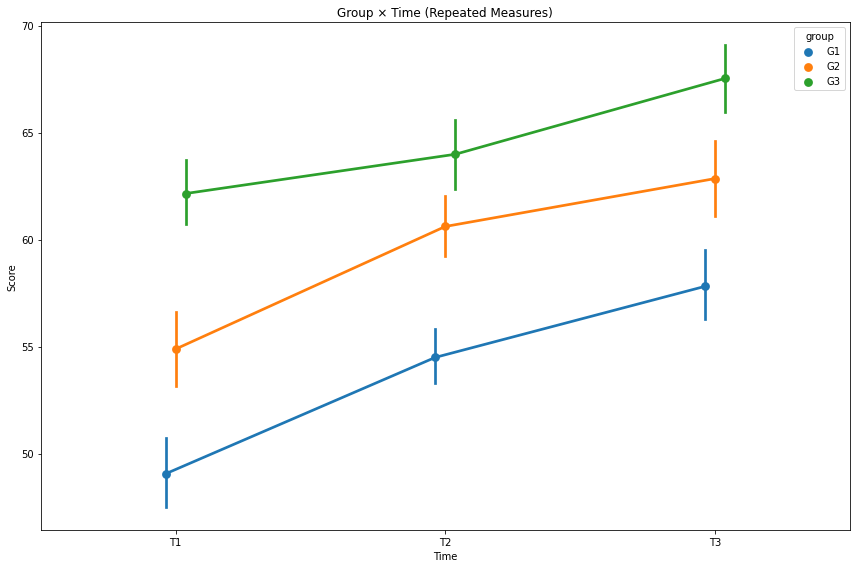

In [83]:
plt.figure(figsize=(12,8))
sns.pointplot(data=df, x='time', y='score', hue='group', dodge=True)
plt.title('Group × Time (Repeated Measures)')
plt.xlabel('Time')
plt.ylabel('Score')
plt.tight_layout()
plt.show()